<a href="https://colab.research.google.com/github/jiange12/2026-IQM/blob/main/Stabilizer_Routing_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade pip
!pip install "iqm-client[qiskit]"
!pip install qrisp[iqm]
!pip install numpy==2.0
!pip install matplotlib
!pip install pylatexenc
!pip install pandas
!pip install random

ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.transpiler import Layout
from qiskit.quantum_info import Pauli
import rustworkx as rx
import itertools
import random

In [ ]:

provider = IQMProvider("https://resonance.meetiqm.com",
                       quantum_computer="emerald",
                       token=input("Input your IQM Resonance token"))
backend = provider.get_backend()

Input your IQM Resonance tokenSL3PEEQqAfXp+moptVazH4QdrlJqOKoae0N4NIk+ougBnBbIO2p2gI5dPHsZ3/1s


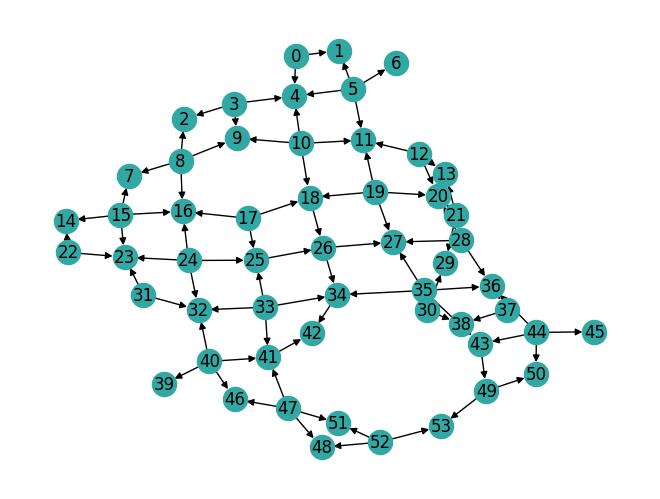

In [ ]:
from rustworkx.visualization import mpl_draw
from rustworkx import spring_layout

mpl_draw(backend.coupling_map.graph, arrows=True, with_labels=True, node_color='#32a8a4', pos=spring_layout(backend.coupling_map.graph, num_iter=200))

In [ ]:
# qubits_names = [
#     #Labels for the qubits that we're going to use
#     "QB41",
#     "QB42",
#     "QB48",
#     "QB49",
#     "QB53",
# ]

qubits_names = [
    #Labels for the qubits that we're going to use
    "QB35",
    "QB27",
    "QB19",
    "QB18",
    "QB26",
    "QB25",
    "QB33",
    "QB34",
    "QB42",
    "QB41",
    # "QB47",
    # "QB48",
    # "QB49",
    # "QB53",
    # "QB54",
]

# Qiskit identifies qubits with integers, so we need to convert those string by using the IQM Backend method
qubits = [backend.qubit_name_to_index(name) for name in qubits_names]
reduced_coupling_map = [list(edge) for edge in backend.coupling_map if set(edge).issubset(set(qubits))]
print("Reduced coupling map: ", reduced_coupling_map)

Reduced coupling map:  [[17, 18], [17, 25], [18, 26], [24, 25], [24, 32], [25, 26], [26, 34], [33, 25], [33, 32], [33, 34], [33, 41], [40, 32], [40, 41]]


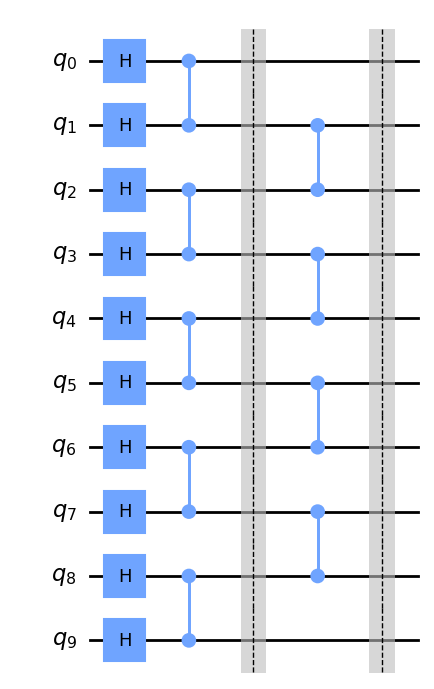

In [ ]:
# This syntax will look a little different than you're used to because we need to use Qiskit in order to do custom transpilation later.

from qiskit.visualization import plot_histogram

# Lock mapping: circuit qubit i -> backend qubit qubits[i]
initial_layout = qubits

# initial_layout = Layout.from_intlist(qubits, qc.qregs[0])


num_qb = len(qubits_names)
# Instead of QuantumVariable, we use QuantumCircuit
qc = QuantumCircuit(num_qb)

# Apply Hadamard gates to all qubits for a cluster state
for qb in range(num_qb):
    qc.h(qb)

# Apply CZ gates between logically adjacent qubits for a linear cluster state
for qb in range(0, num_qb - 1, 2):
    qc.cz(qb, qb + 1)

qc.barrier()

for qb in range(1, num_qb - 1, 2):
    qc.cz(qb, qb + 1)

qc.barrier()

qc.draw("mpl",  style="clifford")

In [ ]:
class BitstringWindowError(ValueError):
    """Raised when inputs to generate_bitstrings() are invalid."""
    pass


def generate_bitstrings(bitstring: int, k: int) -> List[str]:
    """
    Generate all bitstrings of length `bitstring` such that among indices {k-1, k, k+1}
    that are in-bounds, the number of 1s in that window is EVEN.

    Args:
        bitstring: length of the bitstring (must be positive int)
        k: zero-based index into the bitstring (must satisfy 0 <= k < bitstring)

    Returns:
        List of bitstrings as strings of '0'/'1'.

    Raises:
        BitstringWindowError: for invalid inputs
    """
    # --- Type checks (catch floats/strings/etc.) ---
    if not isinstance(bitstring, int) or isinstance(bitstring, bool):
        raise BitstringWindowError(f"bitstring must be an int > 0, got {type(bitstring).__name__}")
    if not isinstance(k, int) or isinstance(k, bool):
        raise BitstringWindowError(f"k must be an int, got {type(k).__name__}")

    # --- Value checks ---
    if bitstring <= 0:
        raise BitstringWindowError(f"bitstring must be > 0, got {bitstring}")
    if k < 0 or k >= bitstring:
        raise BitstringWindowError(
            f"k is out of bounds: got k={k}, but valid range is 0..{bitstring-1} for bitstring={bitstring}"
        )
    window_idxs = [idx for idx in (k - 1, k, k + 1) if 0 <= idx < bitstring]
    other_idxs = [idx for idx in range(bitstring) if idx not in window_idxs]

    results: List[str] = []

    # Window patterns: descending
    for win_pat in range((1 << len(window_idxs)) - 1, -1, -1):
        ones_cnt = win_pat.bit_count()  # Python 3.8+: use bin(win_pat).count("1") if needed
        if (ones_cnt & 1) != 0:
            continue  # reject odd parity

        # Other bits: ascending
        for oth_pat in range(0, 1 << len(other_idxs)):
            bits = ['0'] * bitstring

            for pos, idx in enumerate(window_idxs):
                shift = (len(window_idxs) - 1 - pos)
                bits[idx] = '1' if ((win_pat >> shift) & 1) else '0'

            for pos, idx in enumerate(other_idxs):
                shift = (len(other_idxs) - 1 - pos)
                bits[idx] = '1' if ((oth_pat >> shift) & 1) else '0'

            results.append("".join(bits))

    return results

In [ ]:
# Verify that each adjacent logical pair (i,i+1) exists as an edge in reduced map under your fixed layout
edges = {tuple(sorted(e)) for e in reduced_coupling_map}
missing = []
for i in range(num_qb - 1):
    a = qubits[i]
    b = qubits[i + 1]
    if tuple(sorted((a, b))) not in edges:
        missing.append((i, i+1, a, b))

if missing:
    print("WARNING: Missing physical couplings for intended chain edges:")
    for (i, j, a, b) in missing:
        print(f"  logical ({i},{j}) maps to physical ({a},{b}) which is NOT in reduced coupling map")
else:
    print("Chain connectivity OK for intended mapping.")


Chain connectivity OK for intended mapping.


In [ ]:
def build_linear_cluster_circuit(num_qb: int) -> QuantumCircuit:
    """
    Ideal logical 1D cluster state prep (no measurement).
    Matches your original: H on all, CZ on (0,1),(2,3)... then (1,2),(3,4)...
    """
    qc = QuantumCircuit(num_qb, name=f"linear_cluster_{num_qb}")
    for qb in range(num_qb):
        qc.h(qb)

    for qb in range(0, num_qb - 1, 2):
        qc.cz(qb, qb + 1)
    qc.barrier()

    for qb in range(1, num_qb - 1, 2):
        qc.cz(qb, qb + 1)
    qc.barrier()
    return qc


def build_ghz_circuit(num_qb: int) -> QuantumCircuit:
    """
    GHZ on a line: H(0) then entangle along chain with CX.
    If backend basis favors CZ, transpiler will map; this is logical-level.
    """
    qc = QuantumCircuit(num_qb, name=f"ghz_{num_qb}")
    qc.h(0)
    for i in range(num_qb - 1):
        qc.cx(i, i + 1)
    qc.barrier()
    return qc


def build_graph_state_circuit(num_qb: int, edge_list_logical: list[tuple[int,int]]) -> QuantumCircuit:
    """
    Graph state: H on all, CZ on edges (logical indices).
    """
    qc = QuantumCircuit(num_qb, name=f"graph_state_{num_qb}")
    for q in range(num_qb):
        qc.h(q)
    for a, b in edge_list_logical:
        qc.cz(a, b)
    qc.barrier()
    return qc


def _basis_change_for_pauli(qc: QuantumCircuit, qubit: int, p: str):
    """
    Apply basis changes so that measuring in Z gives Pauli p.
      X: H
      Y: Sdg then H
      Z/I: none (I means ignore bit later, but still measure)
    """
    p = p.upper()
    if p == "X":
        qc.h(qubit)
    elif p == "Y":
        qc.sdg(qubit)
        qc.h(qubit)
    elif p in ("Z", "I"):
        pass
    else:
        raise ValueError(f"Unsupported Pauli letter '{p}'. Use only I,X,Y,Z.")


def add_measurement_setting(qc: QuantumCircuit, setting: str) -> QuantumCircuit:
    """
    Return a measured copy of qc with local basis changes for a Pauli setting string.
    Example settings:
      "ZXZX..." (cluster 2-coloring)
      "XXXX..." (GHZ correlator)
      "ZZZZ..." (computational basis)
      arbitrary mix incl. Y
    """
    if len(setting) != qc.num_qubits:
        raise ValueError(f"setting length {len(setting)} != num_qubits {qc.num_qubits}")

    out = qc.copy()
    out.barrier()
    for i, p in enumerate(setting):
        _basis_change_for_pauli(out, i, p)
    out.measure_all()
    return out


def run_transpiled(
    qc: QuantumCircuit,
    backend,
    reduced_coupling_map,
    initial_layout,
    shots: int,
    optimization_level: int = 3,
):
    """
    Transpile with fixed layout + reduced coupling map, then run and return (counts, transpiled_circuit).
    """
    tqc = transpile(
        qc,
        backend=backend,
        coupling_map=reduced_coupling_map,
        initial_layout=initial_layout,
        optimization_level=optimization_level,
    )
    job = backend.run(tqc, shots=shots)
    res = job.result()
    counts = res.get_counts()
    return counts, tqc


def twoq_metrics(tqc: QuantumCircuit) -> tuple[int, int]:
    """
    Return (2Q_count, 2Q_depth) from a transpiled circuit.
    Counts any instruction with >1 qubit as a 2Q gate (covers CZ/CX/etc).
    """
    twoq_count = 0
    for instr, qargs, cargs in tqc.data:
        if len(qargs) > 1:
            twoq_count += 1

    try:
        twoq_depth = tqc.depth(lambda instr, qargs, cargs: len(qargs) > 1)
    except TypeError:
        # Older qiskit fallback: approximate with total depth
        twoq_depth = tqc.depth()
    return twoq_count, twoq_depth


In [ ]:
def bit_index_for_qubit(i: int, n: int) -> int:
    # counts key is MSB-left; qubit i maps to classical bit (n-1-i)
    return n - 1 - i


def expval_pauli_string_from_counts(counts: dict, setting: str, pauli: str) -> float:
    """
    Estimate <P> where P is a Pauli string over n qubits, measured using 'setting'.
    Assumes measurement outcomes are in Z basis after basis-change gates for 'setting'.

    For each qubit:
      if pauli has I -> ignore bit
      else pauli must match setting at that qubit (X/Y/Z), otherwise not measurable from this setting.
    """
    n = len(setting)
    if len(pauli) != n:
        raise ValueError("pauli length mismatch")

    # Check measurability
    for i in range(n):
        if pauli[i].upper() == "I":
            continue
        if pauli[i].upper() != setting[i].upper():
            raise ValueError(f"Pauli {pauli} not measurable from setting {setting} at qubit {i}")

    shots = sum(counts.values())
    if shots == 0:
        return float("nan")

    total = 0
    for bstr, c in counts.items():
        # bstr index j corresponds to classical bit j (MSB-left)
        parity = 0
        for q in range(n):
            if pauli[q].upper() == "I":
                continue
            j = bit_index_for_qubit(q, n)
            parity ^= (bstr[j] == "1")
        total += (1 if parity == 0 else -1) * c

    return total / shots


def compute_cluster_stabilizers_from_counts(
    counts_setting1: dict,
    counts_setting2: dict,
    num_qb: int,
    setting1: str = None,
    setting2: str = None,
) -> np.ndarray:
    """
    Compute <K_i> for a 1D cluster chain with stabilizers:
      K_0 = X0 Z1
      K_i = Z_{i-1} X_i Z_{i+1} (interior)
      K_{N-1} = Z_{N-2} X_{N-1}

    We assume two-colorable measurement settings:
      setting1: Z X Z X ...  (often "ZXZX...")
      setting2: X Z X Z ...  (often "XZXZ...")
    Odd/even X-centers split across the two settings.
    """
    if setting1 is None:
        setting1 = "".join("Z" if i % 2 == 0 else "X" for i in range(num_qb))
    if setting2 is None:
        setting2 = "".join("X" if i % 2 == 0 else "Z" for i in range(num_qb))

    K = np.zeros(num_qb, dtype=float)

    for i in range(num_qb):
        # Build generator Pauli string for K_i
        p = ["I"] * num_qb
        p[i] = "X"
        if i - 1 >= 0:
            p[i - 1] = "Z"
        if i + 1 < num_qb:
            p[i + 1] = "Z"
        p = "".join(p)

        # Choose which setting measures it (the one that has X at i)
        if setting1[i].upper() == "X":
            K[i] = expval_pauli_string_from_counts(counts_setting1, setting1, p)
        elif setting2[i].upper() == "X":
            K[i] = expval_pauli_string_from_counts(counts_setting2, setting2, p)
        else:
            raise RuntimeError("Neither setting has X at the center qubit; invalid 2-coloring.")
    return K


def fidelity_lower_bound_from_stabilizers_two_setting(K: np.ndarray) -> float:
    """
    Two-setting lower bound (matches the 2-setting cluster witness form):
      F >= Π_even (1+K_i)/2 + Π_odd (1+K_i)/2 - 1
    This corresponds to the stabilizer-based 2-setting cluster witness family. :contentReference[oaicite:1]{index=1}
    """
    n = len(K)
    evens = [i for i in range(n) if i % 2 == 0]
    odds  = [i for i in range(n) if i % 2 == 1]

    prod_even = 1.0
    for i in evens:
        prod_even *= (1.0 + K[i]) / 2.0

    prod_odd = 1.0
    for i in odds:
        prod_odd *= (1.0 + K[i]) / 2.0

    return prod_even + prod_odd - 1.0


def compute_witnesses(K_list: np.ndarray) -> dict:
    """
    Return at least:
      - F_lb: two-setting fidelity lower bound (entanglement if F_lb > 1/2 for projector witness)
      - W_graph: linear stabilizer witness  (N-1) - sum(K_i)
                For connected graph states, <W_graph> < 0 detects genuine N-party entanglement. :contentReference[oaicite:2]{index=2}
    """
    n = len(K_list)
    F_lb = fidelity_lower_bound_from_stabilizers_two_setting(K_list)

    W_graph = (n - 1) - float(np.sum(K_list))

    return {
        "F_lb": F_lb,
        "W_graph": W_graph,  # pass if < 0
        "mean_K": float(np.mean(K_list)),
        "min_K": float(np.min(K_list)),
    }


In [ ]:
def apply_cluster_target_signs(K_list: np.ndarray, bitstring_s: str) -> np.ndarray:
    """
    If the prepared state is |G_s> = Z^s |G>, then ideally:
        <K_i>_{G_s} = (-1)^{s_i}
    To certify fidelity/witness w.r.t. |G_s>, "sign-correct" so the ideal target becomes +1:
        K_tilde[i] = (-1)^{s_i} * K_list[i]
    """
    if len(K_list) != len(bitstring_s):
        raise ValueError("Length mismatch between K_list and bitstring_s")
    signs = np.array([(-1.0 if b == "1" else 1.0) for b in bitstring_s], dtype=float)
    return signs * K_list


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipython-input-3825574493.py:115: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, cargs in tqc.data:


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

...

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

,state_id,bitstring,F_lb,pass_Flb_threshold,W_graph,pass_Wgraph_threshold,mean_K,min_K,2Q_count,2Q_depth
0,0,1101011011,0.519630,True,0.0684,False,0.89316,0.8620,14,5
1,1,1110110001,0.519254,True,0.0692,False,0.89308,0.8652,14,5
2,2,0101111010,0.516974,True,0.0750,False,0.89250,0.8642,14,5
3,3,0101110110,0.516774,True,0.0754,False,0.89246,0.8634,14,5
4,4,1100100001,0.517083,True,0.0746,False,0.89254,0.8606,14,5
5,5,0110111000,0.518247,True,0.0718,False,0.89282,0.8646,14,5
6,6,0100010010,0.517554,True,0.0736,False,0.89264,0.8680,14,5
7,7,1000011011,0.520541,True,0.0656,False,0.89344,0.8624,14,5
8,8,1110111011,0.527139,True,0.0498,False,0.89502,0.8694,14,5
9,9,0000111001,0.531459,True,0.0390,False,0.89610,0.8674,14,5


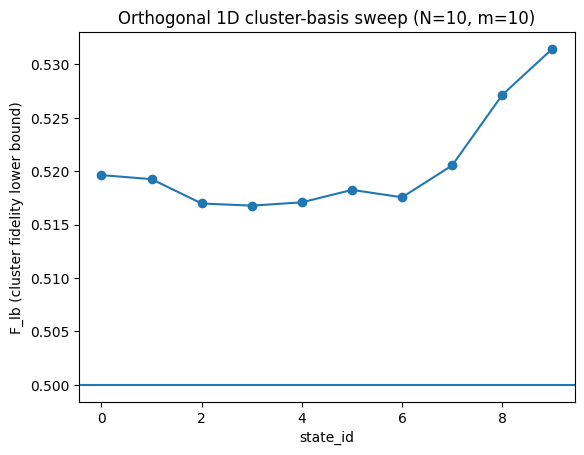

Certified entanglement for 10/10 orthogonal cluster-basis states at N=10 qubits (criterion: F_lb > 1/2).


In [ ]:
def generate_random_bitstrings(m: int, n: int, seed: int = 0) -> list[str]:
    """
    Return m distinct bitstrings length n.
    """
    rng = random.Random(seed)
    seen = set()
    out = []
    max_possible = 2**n
    if m > max_possible:
        raise ValueError("m exceeds number of distinct bitstrings 2^n")

    while len(out) < m:
        s = "".join("1" if rng.random() < 0.5 else "0" for _ in range(n))
        if s not in seen:
            seen.add(s)
            out.append(s)
    return out


def apply_local_z_flips(qc: QuantumCircuit, bitstring: str) -> QuantumCircuit:
    """
    Apply Z on qubit i if bitstring[i] == '1' (immediately after preparation).
    """
    out = qc.copy()
    for i, b in enumerate(bitstring):
        if b == "1":
            out.z(i)
    out.barrier()
    return out


# ---- Run the orthogonal cluster-basis sweep ----
shots = 10_000
m_states = 3
seed = 7

cluster_ideal = build_linear_cluster_circuit(num_qb)

setting_ZXZX = "".join("Z" if i % 2 == 0 else "X" for i in range(num_qb))  # "ZXZX..."
setting_XZXZ = "".join("X" if i % 2 == 0 else "Z" for i in range(num_qb))  # "XZXZ..."

bitstrings = generate_random_bitstrings(m_states, num_qb, seed=seed)

rows = []
for state_id, s in enumerate(bitstrings):
    prep = apply_local_z_flips(cluster_ideal, s)

    qc1 = add_measurement_setting(prep, setting_ZXZX)
    qc2 = add_measurement_setting(prep, setting_XZXZ)

    counts1, tqc1 = run_transpiled(qc1, backend, reduced_coupling_map, initial_layout, shots=shots)
    counts2, tqc2 = run_transpiled(qc2, backend, reduced_coupling_map, initial_layout, shots=shots)

    K_list = compute_cluster_stabilizers_from_counts(counts1, counts2, num_qb, setting1=setting_ZXZX, setting2=setting_XZXZ)

    # NEW: correct stabilizer signs for the target |G_s> = Z^s |G>
    K_tilde = apply_cluster_target_signs(K_list, s)

    # Compute witnesses against the correct target state
    w = compute_witnesses(K_tilde)


    # 2Q metrics: take worst-case across the two settings for reporting
    twoq1, depth1 = twoq_metrics(tqc1)
    twoq2, depth2 = twoq_metrics(tqc2)

    rows.append({
        "state_id": state_id,
        "bitstring": s,
        "F_lb": w["F_lb"],
        "pass_Flb_threshold": (w["F_lb"] > 0.5),
        "W_graph": w["W_graph"],
        "pass_Wgraph_threshold": (w["W_graph"] < 0.0),
        "mean_K": w["mean_K"],
        "min_K": w["min_K"],
        "2Q_count": max(twoq1, twoq2),
        "2Q_depth": max(depth1, depth2),
    })

df_cluster = pd.DataFrame(rows).sort_values("state_id")
display(df_cluster)

# Plot: witness value vs state_id with threshold line (no hardcoded colors)
plt.figure()
plt.plot(df_cluster["state_id"], df_cluster["F_lb"], marker="o", linestyle="-")
plt.axhline(0.5)
plt.xlabel("state_id")
plt.ylabel("F_lb (cluster fidelity lower bound)")
plt.title(f"Orthogonal 1D cluster-basis sweep (N={num_qb}, m={m_states})")
plt.show()

certified = int(df_cluster["pass_Flb_threshold"].sum())
print(f"Certified entanglement for {certified}/{m_states} orthogonal cluster-basis states at N={num_qb} qubits (criterion: F_lb > 1/2).")


## Stablizer Measurements

In [ ]:
def bit_index_for_qubit(i: int, n: int) -> int:
    # counts string index (MSB-left) corresponding to classical bit i
    return n - 1 - i


In [ ]:
def expval_K_from_counts(counts: dict, n: int, center_bit: int) -> float:
    """
    Estimate <K> where K corresponds to parity of bits in {center-1, center, center+1}.
    Even parity -> +1 contribution, odd parity -> -1 contribution.
    counts keys are bitstrings with MSB on the left.
    """
    idxs = [j for j in (center_bit - 1, center_bit, center_bit + 1) if 0 <= j < n]
    shots = sum(counts.values())
    if shots == 0:
        return float("nan")

    total = 0
    for bstr, c in counts.items():
        parity = sum(1 for j in idxs if bstr[j] == "1") & 1
        total += (1 if parity == 0 else -1) * c

    return total / shots


In [ ]:
shots = 10000
# Part 1: ZXZX
qc_p1 = qc.copy(name='qc_p1')
for i in range(num_qb):
  if i % 2 == 1:
    qc_p1.h(i)
qc_p1.measure_all()

qc_p1.draw("mpl",  style="clifford")
qc_p1_transpiled = transpile(
    qc_p1,
    backend=backend,
    coupling_map=reduced_coupling_map,
    initial_layout=initial_layout,
    optimization_level=3,
)
job1 = backend.run(qc_p1_transpiled, shots = shots)
res1 = job1.result()
counts1 = res1.get_counts()

# Centers for qc_p1 (ZXZX): odd i in qubit index -> mapped to bitstring index (num_qb-1-i)
print("shots1 =", sum(counts1.values()))

print(counts1)
# plot_histogram(counts1)

/usr/local/lib/python3.12/dist-packages/qiskit/compiler/transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

shots1 = 10000
{'0000000000': 270, '0011011011': 246, '0011101101': 238, '0000110110': 225, '1101100000': 239, '0011101110': 266, '0000000011': 267, '1110000000': 266, '0011010100': 15, '0011100011': 226, '1011101110': 15, '1101011000': 289, '1101010110': 221, '1110110101': 246, '0011011000': 267, '1101100011': 212, '1110001110': 241, '1101011011': 231, '1101010101': 238, '1100101110': 9, '1110111000': 245, '1110111011': 243, '0000110101': 261, '1110110110': 246, '1101100101': 8, '1101101110': 236, '0000000001': 14, '0011010110': 246, '1110000011': 236, '0000001110': 246, '1110001101': 244, '1110000001': 18, '0000111000': 266, '1000110000': 1, '0000111001': 22, '1000110101': 14, '0000001101': 236, '1110010101': 17, '1101101101': 221, '0011100000': 250, '0011010101': 249, '1101011101': 6, '0110000000': 13, '1101001110': 10, '1101100010': 12, '0101100000': 14, '0110001110': 7, '1001011000': 5, '1110001111': 10, '0110111011': 14, '1000000000': 12, '1101011100': 3, '1100010110': 3, '001111

In [ ]:
shots = 10000
# Part 2: XZXZ
qc_p2 = qc.copy(name='qc_p2')
for i in range(num_qb):
  if i % 2 == 0:
    qc_p2.h(i)
qc_p2.measure_all()

qc_p2_transpiled = transpile(
    qc_p2,
    backend=backend,
    coupling_map=reduced_coupling_map,
    initial_layout=initial_layout,
    optimization_level=3,
)
job2 = backend.run(qc_p2_transpiled, shots = shots)
res2 = job2.result()
counts2 = res2.get_counts()

# Centers for qc_p2 (XZXZ): even i in qubit index -> mapped to bitstring index (num_qb-1-i)
print("shots2 =", sum(counts2.values()))

print(counts2)
# plot_histogram(counts2)

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

shots2 = 10000
{'1101110000': 238, '1100011101': 12, '1011000000': 243, '1010000111': 15, '1111011100': 14, '1100000111': 232, '0000110000': 17, '0111000111': 242, '1010110000': 266, '0110110000': 268, '1100000000': 258, '0111000000': 259, '0000000110': 8, '1100011001': 18, '0000011100': 245, '1101101011': 250, '1011011100': 266, '1010101100': 273, '1101110111': 239, '0001011100': 7, '1101101100': 269, '0110110111': 249, '0000000000': 275, '0111011100': 262, '0111011011': 236, '0001110000': 237, '0001101011': 217, '0110101011': 218, '1011110111': 8, '0000000111': 235, '0000011011': 212, '0000000011': 5, '0111011000': 8, '1100011100': 253, '1110101100': 11, '1000000000': 14, '0001101101': 11, '1100011111': 13, '1010110111': 234, '1010101011': 254, '0001111111': 1, '1010101010': 7, '1011000111': 276, '1011000101': 16, '0001101111': 10, '1011011011': 258, '1000011011': 7, '0100000111': 6, '0001101010': 11, '1100011011': 226, '1100011000': 12, '0110101100': 260, '1100000100': 13, '01110000

In [ ]:
K_list = np.zeros(num_qb, dtype=float)

# From counts1 (ZXZX): odd i are X-centers, so compute odd stabilizers here
for i in range(num_qb):
    if i % 2 == 1:
        center = bit_index_for_qubit(i, num_qb)
        K_list[i] = expval_K_from_counts(counts1, num_qb, center)

# From counts2 (XZXZ): even i are X-centers, so compute even stabilizers here
for i in range(num_qb):
    if i % 2 == 0:
        center = bit_index_for_qubit(i, num_qb)
        K_list[i] = expval_K_from_counts(counts2, num_qb, center)

print("Estimated <K_i>:", K_list)


Estimated <K_i>: [0.8816 0.8768 0.8812 0.8952 0.877  0.8726 0.9074 0.9174 0.9158 0.905 ]


In [ ]:
def fidelity_lower_bound_from_stabilizers(K: np.ndarray) -> float:
    """
    Two-setting lower bound used for 1D cluster/graph states:
      F >= prod_even (1+K_i)/2  +  prod_odd (1+K_i)/2  - 1
    where K_i are stabilizer generator expectation values.
    """
    n = len(K)
    evens = [i for i in range(n) if i % 2 == 0]
    odds  = [i for i in range(n) if i % 2 == 1]

    prod_even = 1.0
    for i in evens:
        prod_even *= (1.0 + K[i]) / 2.0

    prod_odd = 1.0
    for i in odds:
        prod_odd *= (1.0 + K[i]) / 2.0

    F_lb = prod_even + prod_odd - 1.0
    return F_lb


In [ ]:
F_lb = fidelity_lower_bound_from_stabilizers(K_list)
print("Fidelity lower bound F_lb =", F_lb)

if F_lb > 0.5:
    print("Certification: F_lb > 1/2 implies entanglement (projector witness around the cluster state).")
else:
    print("Not certified: F_lb <= 1/2 (with this bound).")


Fidelity lower bound F_lb = 0.5189811473746317
Certification: F_lb > 1/2 implies entanglement (projector witness around the cluster state).


In [ ]:
print(qc_p1_transpiled.count_ops())
print(qc_p2_transpiled.count_ops())


OrderedDict({'r': 15, 'measure': 10, 'cz': 9, 'barrier': 3})
OrderedDict({'r': 15, 'measure': 10, 'cz': 9, 'barrier': 3})


In [ ]:
print(K_list)

[0.8816 0.8768 0.8812 0.8952 0.877  0.8726 0.9074 0.9174 0.9158 0.905 ]


In [ ]:
cluster_pass = int(df_cluster["pass_Flb_threshold"].sum())
cluster_total = len(df_cluster)

print(
    f"Certified entanglement for {cluster_pass}/{cluster_total} "
    f"orthogonal cluster-basis states at N={num_qb} qubits "
    f"(criterion: F_lb > 1/2, sign-corrected for Z^s targets)."
)

Certified entanglement for 10/10 orthogonal cluster-basis states at N=10 qubits (criterion: F_lb > 1/2, sign-corrected for Z^s targets).
